# Handle subWorkflows

### Setting API Keys

In [1]:
import os
from dotenv import load_dotenv

# Load variables from the .env file into the environment
load_dotenv()
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_PROJECT'] = 'Sub-Workflows'
os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")

### Building Basic ChatBot

In [2]:
import os
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START,END,MessagesState,StateGraph
from operator import add
from typing_extensions import TypedDict
from typing import List, Optional, Annotated

os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")
llm = ChatGroq(model="llama3-8b-8192", temperature=0)


# reply = llm.invoke("hi")
# output_parser = StrOutputParser()
# output_parser.parse(reply.content)

In [3]:
class q1_state(TypedDict):
    question : str
    ans_1 : str

class output_q1_state(TypedDict):
    ans_1 : str


def response_1(state):
    question = state["question"]
    if 'Who' in question:
        return {'ans_1' : 'He is a Graduated in Bs Computer Science'}
    
graph_1 = StateGraph(q1_state,output=output_q1_state)
graph_1.add_node("response_1",response_1)

graph_1.add_edge(START,"response_1")
graph_1.add_edge("response_1",END)

app_1 = graph_1.compile()

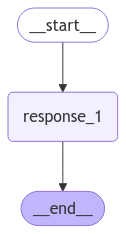

In [4]:
# app_1.invoke({"question" : "Who is Ali"})

from IPython.display import Image, display

try:
    display(Image(app_1.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)
    pass


In [5]:
class q2_state(TypedDict):
    question : str
    ans_2 : str

class output_q2_state(TypedDict):
    ans_2 : str


def response_2(state):
    question = state["question"]
    if 'Who' in question:
        return {'ans_2' : 'Currently he is working as an Ai Engineer'}
    
graph_2 = StateGraph(q2_state,output=output_q2_state)
graph_2.add_node("response_2",response_2)

graph_2.add_edge(START,"response_2")
graph_2.add_edge("response_2",END)

app_2 = graph_2.compile()

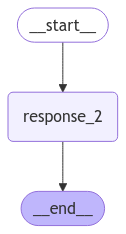

In [6]:
# app_2.invoke({"question" : "Who is Ali"})

from IPython.display import Image, display

try:
    display(Image(app_2.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)
    pass


In [7]:
import operator
from typing import Annotated

class finalState(TypedDict):
    question : Annotated[str, operator.add]

    # question : str
    ans_1 : str
    ans_2: str
    final_ans: str


wokflow=StateGraph(finalState)


def call_model(state):
    context_1 = state["ans_1"]
    context_2 = state["ans_2"]
    question = state["question"]
    msg = f"context :\n {context_1} \n {context_2} \n Main question: {question} \n please provide the answer of question according to given context and donot tell naything extra which you donot know , and make sure to answer like a humen"
    reply = llm.invoke(msg)
    return {"final_ans" : reply.content}



wokflow.add_node("model", call_model)
wokflow.add_node("respose1", graph_1.compile())
wokflow.add_node("respose2", graph_2.compile())

wokflow.add_edge(START, "respose1")
wokflow.add_edge(START, "respose2")
wokflow.add_edge(["respose1", "respose2"], "model")
wokflow.add_edge("model", END)

app=wokflow.compile()

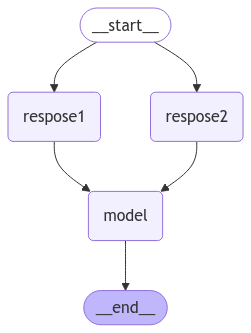

In [8]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
app_1.invoke({"question" : "Who is Ali"})

{'ans_1': 'He is a Graduated in Bs Computer Science'}

In [10]:
app_2.invoke({"question" : "Who is Ali"})

{'ans_2': 'Currently he is working as an Ai Engineer'}

In [11]:
app.invoke({"question" : "Who is Ali"})

{'question': 'Who is Ali',
 'ans_1': 'He is a Graduated in Bs Computer Science',
 'ans_2': 'Currently he is working as an Ai Engineer',
 'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}

In [12]:
for event in app.stream({"question" : "Who is Ali"},stream_mode='values'):
    print(event)
    print("_"*30)

{'question': 'Who is Ali'}
______________________________
{'question': 'Who is Ali', 'ans_1': 'He is a Graduated in Bs Computer Science', 'ans_2': 'Currently he is working as an Ai Engineer'}
______________________________
{'question': 'Who is Ali', 'ans_1': 'He is a Graduated in Bs Computer Science', 'ans_2': 'Currently he is working as an Ai Engineer', 'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}
______________________________


In [13]:
for event in app.stream({"question" : "Who is Ali"},stream_mode='updates'):
    print(event)
    print("_"*30)

{'respose1': {'ans_1': 'He is a Graduated in Bs Computer Science'}}
______________________________
{'respose2': {'ans_2': 'Currently he is working as an Ai Engineer'}}
______________________________
{'model': {'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}}
______________________________
